In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print(movies.shape)
print(ratings.shape)

movies.head()

(9742, 3)
(100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
movie_data = pd.merge(ratings,movies,on='movieId')

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [7]:
movie_data.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

,rating
title,
Karlson Returns (1970),5.0
Zeitgeist: Moving Forward (2011),5.0
"Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)",5.0
Dragons: Gift of the Night Fury (2011),5.0
12 Angry Men (1997),5.0
Justice League: Doom (2012),5.0
Junior and Karlson (1968),5.0
Jump In! (2007),5.0
"Human Condition III, The (Ningen no joken III) (1961)",5.0


In [8]:
movie_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

,rating
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278
Star Wars: Episode IV - A New Hope (1977),251
Jurassic Park (1993),238
Braveheart (1995),237
Terminator 2: Judgment Day (1991),224


In [9]:
ratings_mean = movie_data.groupby('title')['rating'].mean()

ratings_count = movie_data.groupby('title')['rating'].count()

movie_stats = pd.DataFrame({
    'rating': ratings_mean,
    'num ratings': ratings_count
})

movie_stats.head()

,rating,num ratings
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


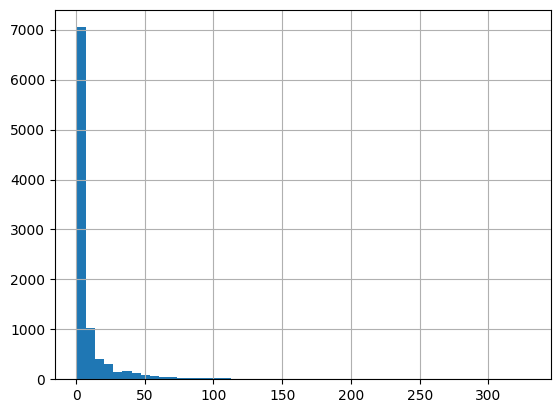

In [10]:
movie_stats['num ratings'].hist(bins=50)
plt.show()

In [11]:
movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

toy_story_ratings = movie_matrix['Toy Story (1995)']

similar_movies = movie_matrix.corrwith(toy_story_ratings)

corr_toy_story = (
    pd.DataFrame(similar_movies, columns=['Correlation'])
    .dropna()
)

corr_toy_story = corr_toy_story[np.isfinite(corr_toy_story['Correlation'])]

corr_toy_story.head()

,Correlation
title,
"'burbs, The (1989)",0.240563
(500) Days of Summer (2009),0.353833
*batteries not included (1987),-0.427425
10 Cent Pistol (2015),1.000000
10 Cloverfield Lane (2016),-0.285732


In [13]:
corr_toy_story = corr_toy_story.join(
    movie_stats['num ratings']
)

recommendations = corr_toy_story[
    corr_toy_story['num ratings'] > 50
].sort_values(
    'Correlation',
    ascending=False
)

recommendations.head(10)

,Correlation,num ratings
title,,
Toy Story (1995),1.000000,215
Toy Story 2 (1999),0.699211,97
Arachnophobia (1990),0.652424,53
"Incredibles, The (2004)",0.643301,125
Finding Nemo (2003),0.618701,141
Aladdin (1992),0.611892,183
Erin Brockovich (2000),0.598016,70
Wallace & Gromit: The Wrong Trousers (1993),0.589625,56
Blazing Saddles (1974),0.585892,62


In [20]:
def recommend(movie_name):

    if movie_name not in movie_matrix.columns:
        return f"Movie '{movie_name}' not found."

    movie_ratings = movie_matrix[movie_name]

    similar_movies = movie_matrix.corrwith(
        movie_ratings,
        method='pearson'
    )

    corr_movie = pd.DataFrame(
        similar_movies,
        columns=['Correlation']
    ).dropna()

    corr_movie = corr_movie.join(
        movie_stats['num ratings']
    )

    recommendations = corr_movie[
        corr_movie['num ratings'] > 50
    ].sort_values(
        by='Correlation',
        ascending=False
    )

    return recommendations.head(10)

In [21]:
recommend("Toy Story (1995)")

,Correlation,num ratings
title,,
Toy Story (1995),1.000000,215
Toy Story 2 (1999),0.699211,97
Arachnophobia (1990),0.652424,53
"Incredibles, The (2004)",0.643301,125
Finding Nemo (2003),0.618701,141
Aladdin (1992),0.611892,183
Erin Brockovich (2000),0.598016,70
Wallace & Gromit: The Wrong Trousers (1993),0.589625,56
Blazing Saddles (1974),0.585892,62


In [16]:
import pandas as pd

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movie_data = pd.merge(ratings,movies,on='movieId')

print(movie_data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [17]:
%%writefile recommendation.py

import pandas as pd

def recommend(movie_name, movie_matrix, movie_stats):

    movie_ratings = movie_matrix[movie_name]

    similar_movies = movie_matrix.corrwith(movie_ratings)

    corr_movie = pd.DataFrame(
        similar_movies,
        columns=['Correlation']
    )

    corr_movie.dropna(inplace=True)

    corr_movie = corr_movie.join(
        movie_stats['num ratings']
    )

    recommendations = corr_movie[
        corr_movie['num ratings'] > 50
    ].sort_values(
        'Correlation',
        ascending=False
    )

    return recommendations.head(10)

Writing recommendation.py


In [18]:
!ls

movies.csv  ratings.csv  recommendation.py  sample_data


In [22]:
from recommendation import recommend

In [23]:
recommend(
    "Toy Story (1995)",
    movie_matrix,
    movie_stats
)

,Correlation,num ratings
title,,
Toy Story (1995),1.000000,215
Toy Story 2 (1999),0.699211,97
Arachnophobia (1990),0.652424,53
"Incredibles, The (2004)",0.643301,125
Finding Nemo (2003),0.618701,141
Aladdin (1992),0.611892,183
Erin Brockovich (2000),0.598016,70
Wallace & Gromit: The Wrong Trousers (1993),0.589625,56
Blazing Saddles (1974),0.585892,62


In [24]:
%%writefile data_preprocessing.py

import pandas as pd

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movie_data = pd.merge(
    ratings,
    movies,
    on="movieId"
)

print(movie_data.head())

Writing data_preprocessing.py


In [25]:
from google.colab import files
files.download("data_preprocessing.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>